<a href="https://colab.research.google.com/github/dherreraal/object_oriented_programming/blob/main/Clase_10/10_POO_Objects_Revisited.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Objetos y Clases (Revisited)
### Universidad Nacional de Colombia
#### **Profesor:** David Alberto Herrera Alvarez
#### **Curso:** Programación Orientada a Objetos (POO)
---

## Índice de Contenido
1. Repaso Práctico: Clases, Objetos y `this`
2. Variables y Métodos de Clase (`static`) vs. de Instancia
3. Pasando y Retornando Objetos a Métodos
4. Sobrecarga (Overloading) de Constructores y Métodos
5. Relaciones entre Clases y Diagramas UML
6. Objetos Recursivos
7. Ejercicios Prácticos
8. Bibliografía y Referencias
---

## 1. Repaso Práctico: Clases, Objetos y `this`
En clases anteriores vimos que una **Clase** es un molde, un **Objeto** es la materialización de esa plantilla, y la palabra reservada **`this`** es el puntero que utiliza un objeto para apuntarse a sí mismo, resolviendo ambigüedades entre los parámetros y los atributos.

Antes de adentrarnos en relaciones más complejas, hagamos un repaso rápido con un ejemplo en código donde vemos todo esto en acción conjunta:

In [1]:
%%writefile Repaso.java
// 1. LA CLASE (El Molde)
class Guerrero {
    // Atributos (Estado)
    String nombre;
    int nivel;

    // Constructor (Usando 'this' para evitar ambigüedades)
    public Guerrero(String nombre, int nivel) {
        this.nombre = nombre; // this.nombre es el atributo, nombre es el parámetro
        this.nivel = nivel;
    }

    // Método (Comportamiento)
    public void presentarse() {
        System.out.println("¡Soy el guerrero " + this.nombre + " de nivel " + this.nivel + "!");
    }
}

public class Repaso {
    public static void main(String[] args) {
        // 2. OBJETOS (Instancias)
        // Cada uno guarda sus propios datos en memoria usando variables de referencia
        Guerrero g1 = new Guerrero("Conan", 10);
        Guerrero g2 = new Guerrero("Leonidas", 25);

        g1.presentarse();
        g2.presentarse();
    }
}

Writing Repaso.java


In [2]:
!javac Repaso.java
!java Repaso

[0.028s][warning][os,container] Cgroup memory controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.028s][warning][os,container] Cgroup cpu controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.001s][warning][os,container] Cgroup memory controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.001s][warning][os,container] Cgroup cpu controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
¡Soy el guerrero Conan de nivel 10!
¡Soy el guerrero Leonidas de nivel 25!


## 2. Variables y Métodos de Clase (`static`) vs. de Instancia
Como vimos en el repaso, normalmente cada vez que creas un objeto con `new`, este recibe **su propia copia** de todas las variables (variables de instancia).

Pero a veces queremos que **todos los objetos de una misma clase compartan un único valor**. Para eso usamos la palabra `static`.

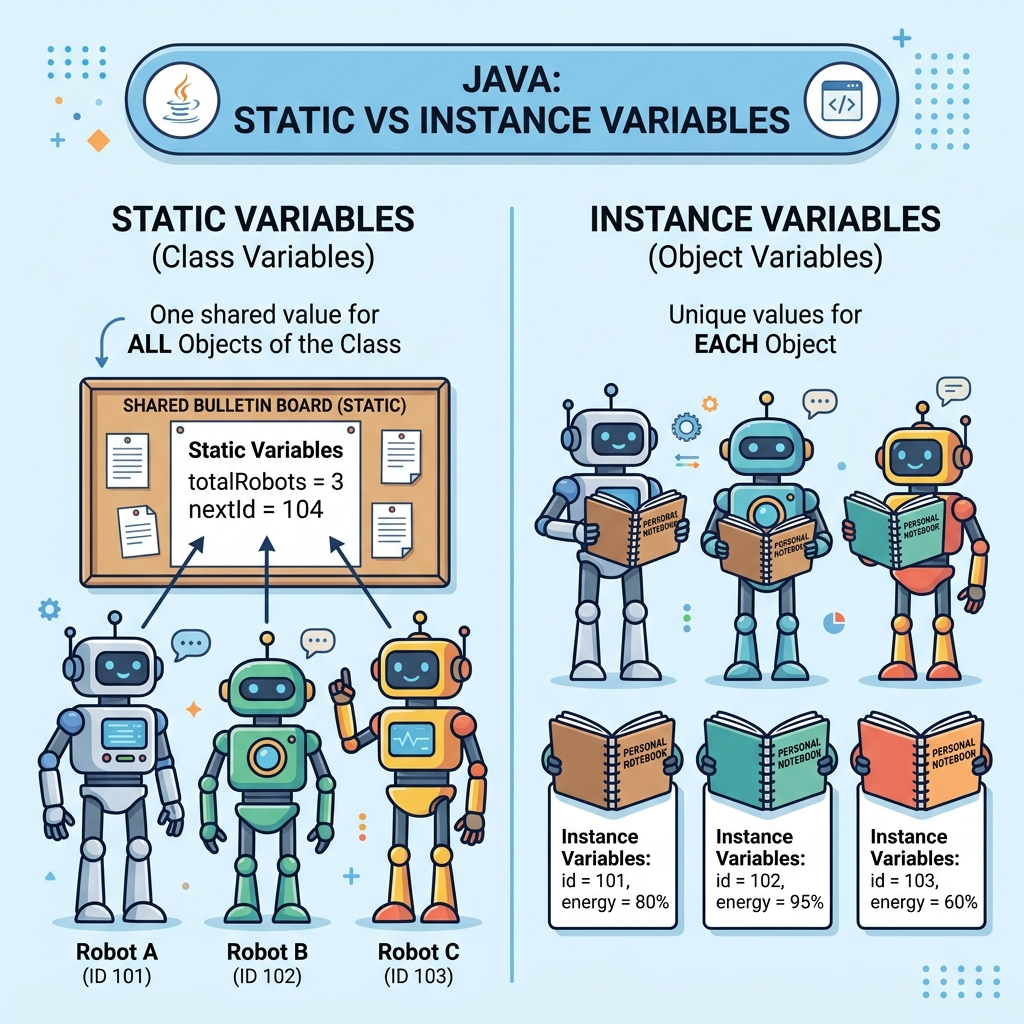
<p style="text-align: center; font-style: italic;">Figura 1: Las variables 'static' son como un tablero de anuncios compartido por todos. Las variables de 'instancia' son libretas personales.</p>

In [3]:
%%writefile Empleado.java
public class Empleado {
    // Variable de instancia (cada empleado tiene su propio nombre)
    String nombre;

    // Variable STATIC (Compartida por todos los empleados)
    static int contadorEmpleados = 0;

    public Empleado(String nombre) {
        this.nombre = nombre;
        contadorEmpleados++; // Suma 1 a la variable compartida
    }

    public static void main(String[] args) {
        Empleado e1 = new Empleado("Ana");
        Empleado e2 = new Empleado("Carlos");

        // La variable static se accede usando el nombre de la Clase, no del objeto
        System.out.println("Total de empleados contratados: " + Empleado.contadorEmpleados);
    }
}

Writing Empleado.java


In [4]:
!javac Empleado.java
!java Empleado

[0.001s][warning][os,container] Cgroup memory controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.001s][warning][os,container] Cgroup cpu controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.001s][warning][os,container] Cgroup memory controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.001s][warning][os,container] Cgroup cpu controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
Total de empleados contratados: 2


## 3. Pasando y Retornando Objetos a Métodos
Los objetos pueden ser enviados a los métodos como si fueran variables normales, y también pueden ser retornados.

**¡Ojo!** A diferencia de los tipos primitivos (`int`, `boolean`), cuando pasas un objeto a un método, **no pasas una copia de la información, pasas la referencia original (la dirección en memoria)**. Si el método modifica el objeto por dentro, ¡se modificará en todo tu programa!

In [5]:
%%writefile Clinica.java
class Paciente {
    String nombre;
    int salud = 50;

    Paciente(String n) { this.nombre = n; }
}

public class Clinica {
    // Método que RECIBE un objeto Paciente y lo modifica
    public static void curar(Paciente p) {
        p.salud = 100;
        System.out.println(p.nombre + " ha sido curado por el médico.");
    }

    public static void main(String[] args) {
        Paciente juan = new Paciente("Juan");
        System.out.println("Salud antes de ir al médico: " + juan.salud);

        curar(juan); // Pasamos la referencia del objeto

        System.out.println("Salud al salir del médico: " + juan.salud);
    }
}

Writing Clinica.java


In [6]:
!javac Clinica.java
!java Clinica

[0.001s][warning][os,container] Cgroup memory controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.001s][warning][os,container] Cgroup cpu controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.001s][warning][os,container] Cgroup memory controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.001s][warning][os,container] Cgroup cpu controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
Salud antes de ir al médico: 50
Juan ha sido curado por el médico.
Salud al salir del médico: 100


## 4. Sobrecarga (Overloading) de Constructores y Métodos
La sobrecarga permite tener **varios métodos o constructores con el mismo nombre** dentro de una clase, SIEMPRE Y CUANDO la cantidad de parámetros o el tipo de datos de los parámetros sean diferentes.

Esto es útil para dar flexibilidad a la hora de crear objetos. Por ejemplo, al abrir una cuenta bancaria, podemos abrirla vacía o con un depósito inicial.

In [7]:
%%writefile CuentaBancaria.java
public class CuentaBancaria {
    double saldo;

    // Constructor 1: Se crea la cuenta sin saldo inicial
    public CuentaBancaria() {
        this.saldo = 0.0;
    }

    // Constructor 2 (SOBRECARGADO): Se crea con un depósito inicial
    public CuentaBancaria(double saldoInicial) {
        this.saldo = saldoInicial;
    }

    public static void main(String[] args) {
        CuentaBancaria cuenta1 = new CuentaBancaria(); // Llama al Constructor 1
        CuentaBancaria cuenta2 = new CuentaBancaria(500.0); // Llama al Constructor 2

        System.out.println("Saldo Cuenta 1: $" + cuenta1.saldo);
        System.out.println("Saldo Cuenta 2: $" + cuenta2.saldo);
    }
}

Writing CuentaBancaria.java


In [8]:
!javac CuentaBancaria.java
!java CuentaBancaria

[0.001s][warning][os,container] Cgroup memory controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.001s][warning][os,container] Cgroup cpu controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.001s][warning][os,container] Cgroup memory controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.001s][warning][os,container] Cgroup cpu controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
Saldo Cuenta 1: $0.0
Saldo Cuenta 2: $500.0


## 5. Relaciones entre Clases y Diagramas UML
En sistemas del mundo real, un objeto casi nunca está solo. Los objetos colaboran formando **relaciones**. El UML (Unified Modeling Language) nos permite dibujar estas relaciones de manera estándar para diseñar el software antes de programarlo.

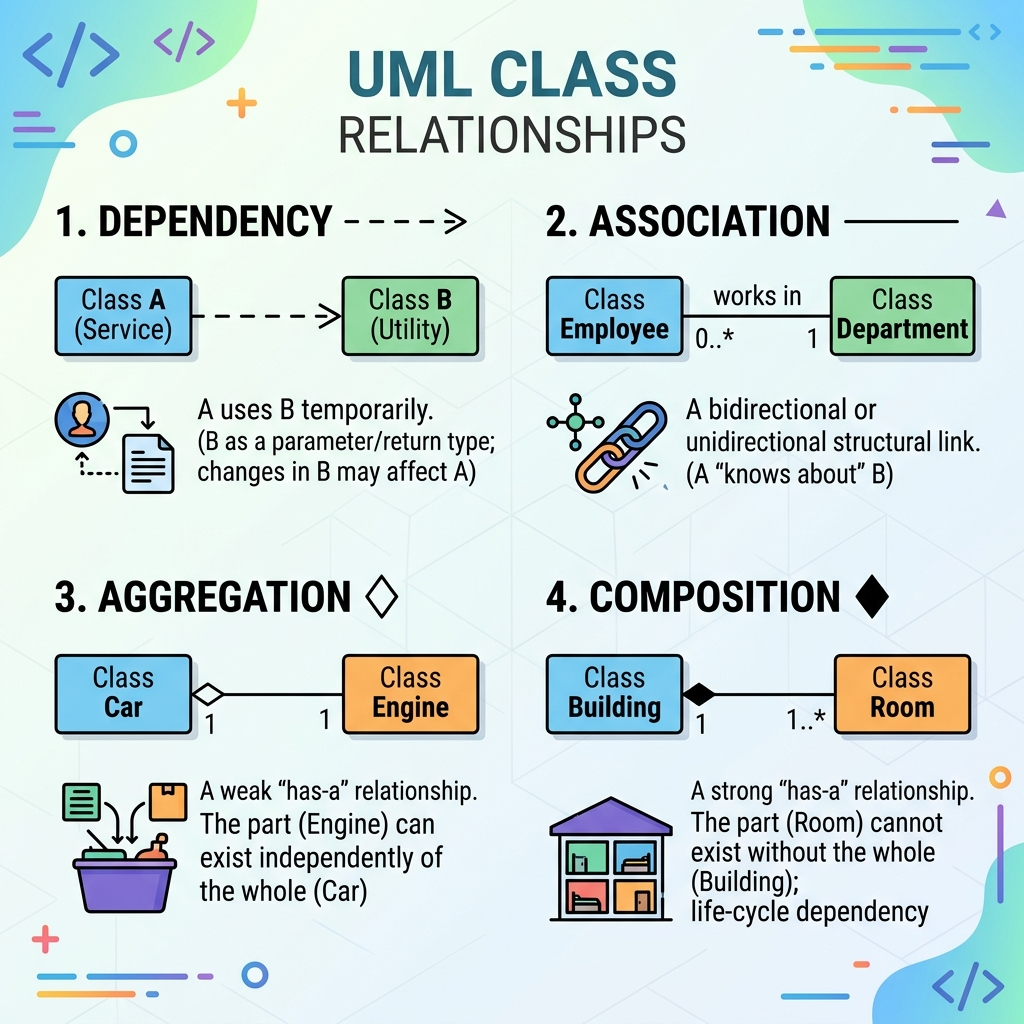
<p style="text-align: center; font-style: italic;">Figura 2: Los 4 principales tipos de relaciones estructurales entre clases en UML.</p>

### Las 4 grandes relaciones:
1. **Dependencia (Usa un):** Una clase necesita a la otra temporalmente (ej. la clase `Clinica` usa a `Paciente` como parámetro temporal). Línea punteada con flecha.
2. **Asociación (Conoce a):** Una relación estructural plana y persistente. Una clase tiene un atributo del tipo de la otra clase, pero son independientes en su existencia. Línea sólida.
3. **Agregación (Tiene un - Débil):** Una clase está conformada por otras, pero si la clase principal se destruye, las partes siguen existiendo por separado (ej. `Universidad` y `Profesor`). Se dibuja con un Rombo vacío.
4. **Composición (Tiene un - Fuerte):** Una clase está conformada por otras, y si la clase principal se destruye, sus partes TAMBIÉN se destruyen obligatoriamente porque no tienen sentido por sí solas (ej. `Casa` y `Habitacion`). Se dibuja con un Rombo relleno.

## 6. Objetos Recursivos
Un caso muy particular de asociación es cuando **una clase tiene como atributo a un objeto de su misma clase**.
A esto se le conoce como un objeto recursivo o auto-referenciado.

Es extremadamente útil para crear estructuras de datos encadenadas, como una **Lista Enlazada** o el árbol genealógico de una persona (una persona tiene una madre, que también es de clase persona).

In [9]:
%%writefile Persona.java
public class Persona {
    String nombre;
    // Objeto recursivo: el atributo es de la MISMA clase Persona
    Persona padre;

    public Persona(String nombre) {
        this.nombre = nombre;
    }

    public static void main(String[] args) {
        Persona hijo = new Persona("Luke Skywalker");
        Persona papa = new Persona("Darth Vader");

        // Relacionamos los objetos a través de su atributo recursivo
        hijo.padre = papa;

        System.out.println(hijo.nombre + " es hijo de " + hijo.padre.nombre);
    }
}

Writing Persona.java


In [10]:
!javac Persona.java
!java Persona

[0.001s][warning][os,container] Cgroup memory controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.001s][warning][os,container] Cgroup cpu controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.001s][warning][os,container] Cgroup memory controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.001s][warning][os,container] Cgroup cpu controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
Luke Skywalker es hijo de Darth Vader


## 7. Ejercicios Prácticos

---
### Ejercicio 1: Sobrecarga de Métodos
**Enunciado:** Crea una clase `Calculadora` que tenga dos métodos estáticos (static) sobrecargados llamados `sumar`. El primero debe recibir dos enteros (`int`) y retornar su suma. El segundo debe recibir tres enteros (`int`) y retornar su suma. Pruébalos en el `main`.

In [11]:
%%writefile Ejercicio1.java
public class Ejercicio1 {

    // TU CÓDIGO AQUÍ: Crea el primer método sumar


    // TU CÓDIGO AQUÍ: Crea el segundo método sumar (sobrecargado)


    public static void main(String[] args) {
        // Prueba tus dos métodos aquí:

    }
}

Writing Ejercicio1.java


In [12]:
!javac Ejercicio1.java
!java Ejercicio1

[0.001s][warning][os,container] Cgroup memory controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.001s][warning][os,container] Cgroup cpu controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.001s][warning][os,container] Cgroup memory controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.001s][warning][os,container] Cgroup cpu controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate


---
### Ejercicio 2: Agregación (Asociación Débil)
**Enunciado:** Crea una clase `Motor` con un atributo `caballosDeFuerza`. Luego, crea una clase `Carro` que tenga como atributo un objeto de la clase `Motor` (esto es una relación de Agregación). Crea un `Carro`, asígnale un `Motor`, e imprime la potencia del carro accediendo a través de su objeto motor.

In [13]:
%%writefile Ejercicio2.java
class Motor {
    // TU CÓDIGO AQUÍ
}

class Carro {
    // TU CÓDIGO AQUÍ (Debe contener una variable del tipo Motor)
}

public class Ejercicio2 {
    public static void main(String[] args) {
        // Crea los objetos y relacionálos aquí:

    }
}

Writing Ejercicio2.java


In [14]:
!javac Ejercicio2.java
!java Ejercicio2

[0.000s][warning][os,container] Cgroup memory controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.001s][warning][os,container] Cgroup cpu controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.001s][warning][os,container] Cgroup memory controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.001s][warning][os,container] Cgroup cpu controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate


## 8. Bibliografía y Referencias
- **León, G., Rodríguez, A., Gómez, J., Cubides, C. & Sierra, C.A.** Relaciones de Objetos y Clases (Diapositivas de clase). Universidad Nacional de Colombia.
- **Streib, J. T., & Soma, T. (2014).** Guide to Java: A Concise Introduction to Programming. Springer. (Capítulo 5: Objects: Revisited).
- **Oracle Java Documentation:** [Understanding Class Members](https://docs.oracle.com/javase/tutorial/java/javaOO/classvars.html)